# Random Forest person identification

This baseline uses the frozen 91-feature dataset and the same 1,440 exhaustive one-trial-per-person holdouts as the SVM experiments. All phases and cycles of each held-out recording stay together. No PCA or scaling is needed for this tree model.

**Fixed configuration, not tuned:** 100 trees, `max_features="sqrt"`, `min_samples_leaf=2`, balanced class weights, and seed 42. These settings were chosen before inspecting Random Forest results. Any future tuning must use trial-grouped validation inside the training portion of each outer split.

All supplied cycles are retained, including quality-flagged cycles, to match the SVM baseline. Repeated predictions of a cycle across splits are **not independent observations**. Split standard deviations describe sensitivity to the held-out recordings, not uncertainty from independent experiments. This evaluates identification of the five known participants on held-out recordings.

In [1]:
# CELL 1 - Project paths and imports
from pathlib import Path
from itertools import product
import hashlib
import json
import platform
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display
from joblib import Parallel, delayed
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

PROJECT_ROOT = next(
    (p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
     if (p / "trial_manifest.json").is_file() and (p / "analysis").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Launch from the project root or analysis folder.")
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FEATURE_FILE = RESULTS_DIR / "cycle_features_with_quality.csv"
print("Feature file:", FEATURE_FILE)
print("scikit-learn:", sklearn.__version__)

Feature file: C:\Users\MSI\OneDrive\Desktop\Gait and Posture\new G&P\results\cycle_features_with_quality.csv
scikit-learn: 1.6.1


In [2]:
# CELL 2 - Load and validate the frozen feature dataset
df = pd.read_csv(FEATURE_FILE)
META_COLS = ["person", "trial", "phase", "cycle_index", "frames", "cycle_quality"]
KEY_COLS = ["person", "trial", "phase", "cycle_index"]
feature_cols = [c for c in df.columns if c not in META_COLS]
assert len(feature_cols) == 91
assert df[KEY_COLS].notna().all().all()
assert not df.duplicated(KEY_COLS).any()
assert np.isfinite(df[feature_cols].to_numpy(dtype=float)).all()
df["group_id"] = df["person"].astype(str) + "_T" + df["trial"].astype(str)
people = sorted(df["person"].unique())
trials_by_person = {
    p: sorted(df.loc[df["person"] == p, "trial"].unique()) for p in people
}
assert all(len(t) >= 2 for t in trials_by_person.values())
holdout_combinations = list(product(*(trials_by_person[p] for p in people)))
assert len(holdout_combinations) == 1440, "Dataset differs from the original comparison."
print("Cycles:", len(df), "Features:", len(feature_cols))
print("Recordings:", df["group_id"].nunique(), "Holdout combinations:", len(holdout_combinations))
display(df.groupby("person").agg(cycles=("trial", "size"), trials=("trial", "nunique")))

# Refuse a misleading comparison if baseline predictions cover different cycles/splits.
BASELINE_FILES = {
    "Linear SVM": "model_a_cycle_predictions.csv",
    "PCA + Linear SVM": "model_b_pca_cycle_predictions.csv",
}
baseline_predictions = {}
for label, filename in BASELINE_FILES.items():
    old = pd.read_csv(RESULTS_DIR / filename)
    assert not old.duplicated(["split_id"] + KEY_COLS).any()
    unique_keys = old[KEY_COLS].drop_duplicates()
    check = df[KEY_COLS].merge(unique_keys, on=KEY_COLS, how="outer", indicator=True)
    assert check["_merge"].eq("both").all(), f"Cycle mismatch: {label}"
    assert set(old["split_id"]) == set(range(1, len(holdout_combinations) + 1))
    grouped = old.groupby("split_id")
    for sid, combo in enumerate(holdout_combinations, 1):
        actual = set(map(tuple, grouped.get_group(sid)[["person", "trial"]].drop_duplicates().to_numpy()))
        assert actual == set(zip(people, combo)), f"Holdout mismatch: {label}, split {sid}"
    baseline_predictions[label] = old
print("Saved SVM cycle identities and holdout assignments verified.")

Cycles: 435 Features: 91
Recordings: 22 Holdout combinations: 1440


,cycles,trials
person,,
Buddhini,77,6
Harshika,59,5
Muthuni,30,3
Nadeera,124,4
Thenuri,145,4


Saved SVM cycle identities and holdout assignments verified.


In [3]:
# CELL 3 - Fixed Random Forest configuration
RF_PARAMS = dict(
    n_estimators=100,
    max_features="sqrt",
    min_samples_leaf=2,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=1,  # Parallelize across splits instead of nesting parallel workers.
)
PARALLEL_SPLITS = 4  # Set to 1 if memory is limited.
X = df[feature_cols].to_numpy(dtype=float)
y = df["person"].to_numpy()
trial_ids = df["trial"].to_numpy()
group_ids = df["group_id"].to_numpy()
print(RF_PARAMS)

def evaluate_split(split_id, heldout_trials):
    test_mask = np.zeros(len(df), dtype=bool)
    for person, trial in zip(people, heldout_trials):
        test_mask |= (y == person) & (trial_ids == trial)
    assert set(group_ids[~test_mask]).isdisjoint(set(group_ids[test_mask]))
    assert set(y[~test_mask]) == set(people)
    model = RandomForestClassifier(**RF_PARAMS)
    model.fit(X[~test_mask], y[~test_mask])
    predicted = model.predict(X[test_mask])
    metrics = {
        "split_id": split_id,
        "accuracy": accuracy_score(y[test_mask], predicted),
        "balanced_accuracy": balanced_accuracy_score(y[test_mask], predicted),
        "macro_f1": f1_score(y[test_mask], predicted, labels=people, average="macro", zero_division=0),
        "test_cycles": int(test_mask.sum()),
    }
    predictions = df.loc[test_mask, KEY_COLS + ["group_id", "cycle_quality"]].copy()
    predictions["split_id"] = split_id
    predictions["predicted_person"] = predicted
    predictions["correct"] = predicted == y[test_mask]
    return metrics, predictions

{'n_estimators': 100, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'max_depth': None, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': 1}


In [4]:
# CELL 4 - Evaluate all 1,440 holdouts (this is the main computation)
started = time.perf_counter()
outputs = []
BATCH_SIZE = 120
with Parallel(n_jobs=PARALLEL_SPLITS) as parallel:
    for start in range(0, len(holdout_combinations), BATCH_SIZE):
        batch = holdout_combinations[start:start + BATCH_SIZE]
        outputs.extend(parallel(
            delayed(evaluate_split)(start + offset + 1, combo)
            for offset, combo in enumerate(batch)
        ))
        print(f"Completed {len(outputs)}/{len(holdout_combinations)} splits", flush=True)
rf_results = pd.DataFrame([result[0] for result in outputs])
rf_predictions = pd.concat([result[1] for result in outputs], ignore_index=True)
elapsed_seconds = time.perf_counter() - started
assert len(rf_results) == len(holdout_combinations)
assert not rf_predictions.duplicated(["split_id"] + KEY_COLS).any()
assert len(rf_predictions) == int(rf_results["test_cycles"].sum())
expected_counts = df["person"].map({p: len(holdout_combinations) // len(t) for p, t in trials_by_person.items()})
assert len(rf_predictions) == int(expected_counts.sum())
assert (rf_predictions.groupby(KEY_COLS).size().sort_index().to_numpy()
        == df.assign(expected=expected_counts).set_index(KEY_COLS)["expected"].sort_index().to_numpy()).all()
print(f"Completed in {elapsed_seconds / 60:.2f} minutes.")
print("Repeated held-out cycle predictions:", len(rf_predictions))

Completed 120/1440 splits


Completed 240/1440 splits


Completed 360/1440 splits


Completed 480/1440 splits


Completed 600/1440 splits


...

Completed 1080/1440 splits


Completed 1200/1440 splits


Completed 1320/1440 splits


Completed 1440/1440 splits


Completed in 1.82 minutes.
Repeated held-out cycle predictions: 146712


In [5]:
# CELL 5 - Split-level metrics and pooled per-person performance
metric_cols = ["accuracy", "balanced_accuracy", "macro_f1"]
rf_summary = rf_results[metric_cols].agg(["mean", "std", "min", "max"]).T.mul(100)
rf_summary.index.name = "metric"
print("Metrics across splits (%):")
display(rf_summary.round(2))

def per_person_metrics(predictions):
    precision, recall, f1, support = precision_recall_fscore_support(
        predictions["person"], predictions["predicted_person"], labels=people, zero_division=0
    )
    return pd.DataFrame({
        "person": people, "precision_pct": precision * 100,
        "identification_rate_pct": recall * 100, "f1_pct": f1 * 100,
        "error_rate_pct": (1 - recall) * 100, "repeated_predictions": support,
    })
rf_per_person = per_person_metrics(rf_predictions)
display(rf_per_person.round(2))
print("Pooled cycle accuracy (%):", round(rf_predictions["correct"].mean() * 100, 2))
print("Pooled accuracy weights split results by test-set size; it can differ from mean split accuracy.")

Metrics across splits (%):


,mean,std,min,max
metric,,,,
accuracy,91.06,4.79,73.27,100.0
balanced_accuracy,88.58,7.66,63.37,100.0
macro_f1,87.06,7.86,63.67,100.0


,person,precision_pct,identification_rate_pct,f1_pct,error_rate_pct,repeated_predictions
0,Buddhini,80.45,80.93,80.69,19.07,18480
1,Harshika,79.04,93.33,85.59,6.67,16992
2,Muthuni,96.52,72.44,82.76,27.56,14400
3,Nadeera,99.47,95.30,97.34,4.70,44640
4,Thenuri,91.12,95.11,93.07,4.89,52200


Pooled cycle accuracy (%): 90.95
Pooled accuracy weights split results by test-set size; it can differ from mean split accuracy.


,Buddhini,Harshika,Muthuni,Nadeera,Thenuri
true_person,,,,,
Buddhini,80.93,0.91,0.81,0.69,16.67
Harshika,4.44,93.33,1.18,0.53,0.51
Muthuni,15.36,4.28,72.44,0.06,7.86
Nadeera,0.48,3.00,0.01,95.30,1.20
Thenuri,0.87,3.99,0.04,0.00,95.11


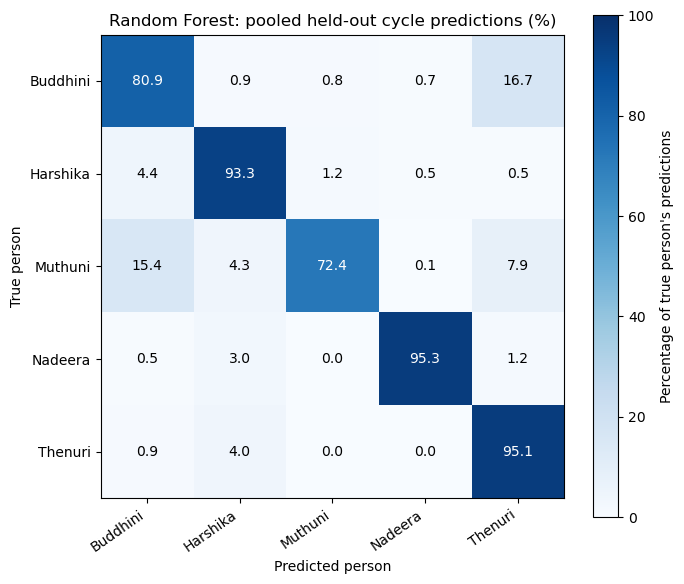

In [6]:
# CELL 6 - Row-normalized confusion matrix
cm = confusion_matrix(rf_predictions["person"], rf_predictions["predicted_person"], labels=people)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
rf_confusion = pd.DataFrame(cm_pct, index=people, columns=people)
rf_confusion.index.name = "true_person"
display(rf_confusion.round(2))
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=100)
ax.set_xticks(range(len(people)), people, rotation=35, ha="right")
ax.set_yticks(range(len(people)), people)
ax.set_xlabel("Predicted person")
ax.set_ylabel("True person")
ax.set_title("Random Forest: pooled held-out cycle predictions (%)")
for i in range(len(people)):
    for j in range(len(people)):
        ax.text(j, i, f"{cm_pct[i, j]:.1f}", ha="center", va="center",
                color="white" if cm_pct[i, j] > 50 else "black")
fig.colorbar(im, ax=ax, label="Percentage of true person's predictions")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "rf_confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.show()

In [7]:
# CELL 7 - Cycle errors by recording and whole-trial majority voting
rf_trial_errors = rf_predictions.groupby(["person", "trial"])["correct"].agg(
    repeated_predictions="size", correct_predictions="sum"
).reset_index()
rf_trial_errors["errors"] = rf_trial_errors["repeated_predictions"] - rf_trial_errors["correct_predictions"]
rf_trial_errors["error_rate_pct"] = 100 * rf_trial_errors["errors"] / rf_trial_errors["repeated_predictions"]
rf_trial_errors = rf_trial_errors.sort_values("error_rate_pct", ascending=False)

def majority_vote(values):
    counts = values.value_counts()
    return sorted(counts[counts == counts.max()].index)[0]  # Same deterministic tie rule as Model A.

rf_trial_predictions = rf_predictions.groupby(["split_id", "person", "trial"], as_index=False).agg(
    predicted_person=("predicted_person", majority_vote), n_cycles=("predicted_person", "size")
)
rf_trial_predictions["correct"] = rf_trial_predictions["person"] == rf_trial_predictions["predicted_person"]
rf_trial_stability = rf_trial_predictions.groupby(["person", "trial"])["correct"].agg(
    correct_count="sum", total_tests="size"
).reset_index()
rf_trial_stability["correct_pct"] = 100 * rf_trial_stability["correct_count"] / rf_trial_stability["total_tests"]
print("Cycle-level error by recording:")
display(rf_trial_errors.round(2))
print("Whole-trial majority-vote stability:")
display(rf_trial_stability.round(2))

Cycle-level error by recording:


,person,trial,repeated_predictions,correct_predictions,errors,error_rate_pct
11,Muthuni,1,4800,1463,3337,69.52
5,Buddhini,9,4320,1824,2496,57.78
10,Harshika,5,2592,1745,847,32.68
4,Buddhini,7,3840,3319,521,13.57
1,Buddhini,2,3600,3154,446,12.39
13,Muthuni,3,5280,4648,632,11.97
20,Thenuri,3,15840,14421,1419,8.96
15,Nadeera,2,15120,14054,1066,7.05
17,Nadeera,4,14760,13915,845,5.72
7,Harshika,2,6048,5762,286,4.73


Whole-trial majority-vote stability:


,person,trial,correct_count,total_tests,correct_pct
0,Buddhini,1,240,240,100.00
1,Buddhini,2,240,240,100.00
2,Buddhini,3,240,240,100.00
3,Buddhini,4,240,240,100.00
4,Buddhini,7,238,240,99.17
5,Buddhini,9,67,240,27.92
6,Harshika,1,288,288,100.00
7,Harshika,2,288,288,100.00
8,Harshika,3,288,288,100.00
9,Harshika,4,288,288,100.00


,model,mean_accuracy_pct,mean_balanced_accuracy_pct,mean_macro_f1_pct,pooled_cycle_accuracy_pct,pooled_trial_vote_accuracy_pct
0,Linear SVM,96.36,95.04,94.82,96.29,99.90
1,PCA + Linear SVM,95.62,93.98,93.81,95.55,99.39
2,Random Forest,91.06,88.58,87.06,90.95,92.33


,person,Linear SVM,PCA + Linear SVM,Random Forest
0,Buddhini,92.15,88.41,80.93
1,Harshika,98.31,98.31,93.33
2,Muthuni,84.85,82.45,72.44
3,Nadeera,98.36,98.38,95.30
4,Thenuri,98.48,98.36,95.11


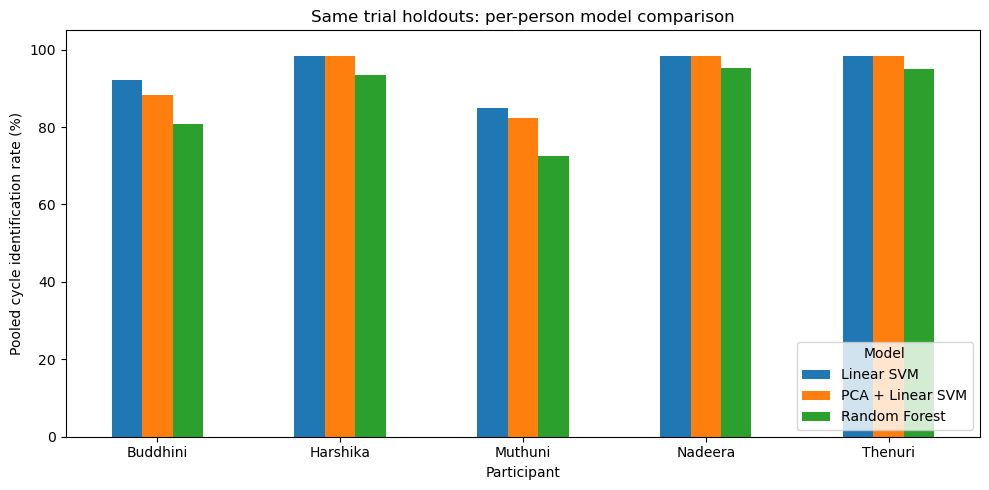

In [8]:
# CELL 8 - Compare the same saved predictions and splits for all three models
all_predictions = {**baseline_predictions, "Random Forest": rf_predictions}
comparison_rows = []
per_person_comparison = pd.DataFrame({"person": people})
for label, predictions in all_predictions.items():
    split_metrics = []
    for _, group in predictions.groupby("split_id"):
        split_metrics.append([
            accuracy_score(group["person"], group["predicted_person"]),
            balanced_accuracy_score(group["person"], group["predicted_person"]),
            f1_score(group["person"], group["predicted_person"], labels=people, average="macro", zero_division=0),
        ])
    split_metrics = np.asarray(split_metrics)
    trial_votes = predictions.groupby(["split_id", "person", "trial"])["predicted_person"].agg(majority_vote)
    trial_correct = trial_votes.to_numpy() == trial_votes.index.get_level_values("person").to_numpy()
    comparison_rows.append({
        "model": label,
        "mean_accuracy_pct": 100 * split_metrics[:, 0].mean(),
        "mean_balanced_accuracy_pct": 100 * split_metrics[:, 1].mean(),
        "mean_macro_f1_pct": 100 * split_metrics[:, 2].mean(),
        "pooled_cycle_accuracy_pct": 100 * (predictions["person"] == predictions["predicted_person"]).mean(),
        "pooled_trial_vote_accuracy_pct": 100 * trial_correct.mean(),
    })
    rates = per_person_metrics(predictions)[["person", "identification_rate_pct"]]
    per_person_comparison = per_person_comparison.merge(
        rates.rename(columns={"identification_rate_pct": label}), on="person", validate="one_to_one"
    )
model_comparison = pd.DataFrame(comparison_rows)
display(model_comparison.round(2))
display(per_person_comparison.round(2))
ax = per_person_comparison.set_index("person").plot.bar(figsize=(10, 5), ylim=(0, 105))
ax.set_ylabel("Pooled cycle identification rate (%)")
ax.set_xlabel("Participant")
ax.set_title("Same trial holdouts: per-person model comparison")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Model", loc="lower right")
ax.figure.tight_layout()
ax.figure.savefig(RESULTS_DIR / "rf_per_person_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

In [9]:
# CELL 9 - Focused check: Muthuni Trial 3 (report only, not used to tune the model)
focus_rows = []
cycle_rows = []
for label, predictions in all_predictions.items():
    selected = predictions[(predictions["person"] == "Muthuni") & (predictions["trial"] == 3)].copy()
    selected["correct"] = selected["person"] == selected["predicted_person"]
    votes = selected.groupby("split_id")["predicted_person"].agg(majority_vote)
    focus_rows.append({
        "model": label,
        "cycle_accuracy_pct": 100 * selected["correct"].mean(),
        "predicted_as_Buddhini_pct": 100 * selected["predicted_person"].eq("Buddhini").mean(),
        "trial_vote_correct_pct": 100 * votes.eq("Muthuni").mean(),
    })
    rates = selected.groupby(["phase", "cycle_index"])["correct"].mean().mul(100).reset_index(name="identification_pct")
    rates["model"] = label
    cycle_rows.append(rates)
rf_muthuni_comparison = pd.DataFrame(focus_rows)
rf_muthuni_cycles = pd.concat(cycle_rows, ignore_index=True)
display(rf_muthuni_comparison.round(2))
display(rf_muthuni_cycles.pivot(index=["phase", "cycle_index"], columns="model", values="identification_pct").round(2))
print("A change in accuracy does not identify the physical cause of the unusual pelvis signals.")

,model,cycle_accuracy_pct,predicted_as_Buddhini_pct,trial_vote_correct_pct
0,Linear SVM,76.88,20.51,100.00
1,PCA + Linear SVM,70.32,28.88,99.38
2,Random Forest,88.03,0.09,100.00


model              Linear SVM  PCA + Linear SVM  Random Forest
phase cycle_index                                             
1     1                100.00            100.00           5.00
      2                100.00            100.00          64.38
      3                 52.08             32.50         100.00
      4                 61.25             27.71         100.00
      5                  0.00              0.00         100.00
      6                100.00             92.50          98.96
      7                100.00             73.54         100.00
      8                100.00            100.00         100.00
      9                 65.42             57.71         100.00
      10                95.62             92.92         100.00
      11                71.25             96.67         100.00

A change in accuracy does not identify the physical cause of the unusual pelvis signals.


In [10]:
# CELL 10 - Save Random Forest outputs separately from the existing SVM files
tables = {
    "rf_exhaustive_results.csv": rf_results,
    "rf_summary.csv": rf_summary.reset_index(),
    "rf_cycle_predictions.csv": rf_predictions,
    "rf_per_person_performance.csv": rf_per_person,
    "rf_trial_error_analysis.csv": rf_trial_errors,
    "rf_trial_predictions.csv": rf_trial_predictions,
    "rf_trial_stability.csv": rf_trial_stability,
    "rf_model_comparison.csv": model_comparison,
    "rf_per_person_comparison.csv": per_person_comparison,
    "rf_muthuni_trial3_comparison.csv": rf_muthuni_comparison,
    "rf_muthuni_trial3_cycles.csv": rf_muthuni_cycles,
}
for filename, table in tables.items():
    table.to_csv(RESULTS_DIR / filename, index=False)
rf_confusion.to_csv(RESULTS_DIR / "rf_confusion_matrix_percent.csv")
configuration = {
    "model": "RandomForestClassifier", "parameters": RF_PARAMS,
    "feature_file": str(FEATURE_FILE.relative_to(PROJECT_ROOT)),
    "feature_sha256": hashlib.sha256(FEATURE_FILE.read_bytes()).hexdigest(),
    "baseline_prediction_sha256": {
        label: hashlib.sha256((RESULTS_DIR / filename).read_bytes()).hexdigest()
        for label, filename in BASELINE_FILES.items()
    },
    "feature_columns": feature_cols, "cycles": len(df),
    "recordings": int(df["group_id"].nunique()), "splits": len(holdout_combinations),
    "sklearn_version": sklearn.__version__, "python_version": platform.python_version(),
    "elapsed_seconds": elapsed_seconds, "tuning": "None; fixed baseline configuration",
    "tie_break": "Alphabetical among tied majority labels",
}
(RESULTS_DIR / "rf_run_config.json").write_text(json.dumps(configuration, indent=2), encoding="utf-8")
print("Saved Random Forest tables, figures, and run configuration to:", RESULTS_DIR)
print("Existing SVM result files were not overwritten.")

Saved Random Forest tables, figures, and run configuration to: C:\Users\MSI\OneDrive\Desktop\Gait and Posture\new G&P\results
Existing SVM result files were not overwritten.


## Interpretation of the executed baseline

With the fixed configuration above, Random Forest achieved **91.06% mean cycle accuracy**, **88.58% mean balanced accuracy**, and **87.06% mean macro F1** across the 1,440 holdouts. Linear SVM remained stronger overall (96.36%, 95.04%, and 94.82%, respectively). These are mean split metrics; pooled cycle metrics use a different weighting.

Muthuni Trial 3 improved from **76.88%** cycle identification with Linear SVM to **88.03%** with Random Forest. Its confusion with Buddhini fell from **20.51% to 0.09%**. Random Forest correctly identified cycles 3–5 in every split, but struggled with cycles 1–2. This demonstrates that the error pattern depends on the classifier; it does not establish the physical cause of the signal differences.

Across all Muthuni trials, identification fell from **84.85% to 72.44%**. Trial 1 was particularly difficult for Random Forest (**30.48%** cycle identification). Therefore the Trial 3 improvement should not be presented as an overall improvement for Muthuni or the dataset.

